In [3]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('Health_Sleep_Statistics.csv')

In [6]:
df.head()

,User ID,Age,Gender,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage
0,1,25,f,8,23:00,06:30,8000,2500,medium,healthy,no,no
1,2,34,m,7,00:30,07:00,5000,2200,low,unhealthy,yes,yes
2,3,29,f,9,22:45,06:45,9000,2700,high,healthy,no,no
3,4,41,m,5,01:00,06:30,4000,2100,low,unhealthy,yes,no
4,5,22,f,8,23:30,07:00,10000,2800,high,medium,no,no


Evaluar si hay una diferencia significativa en la calidad del sueño entre
hombres y mujeres.

In [10]:
men = df[df['Gender'] == 'm']
women = df[df['Gender'] == 'f']

<h3>Box-Plot

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

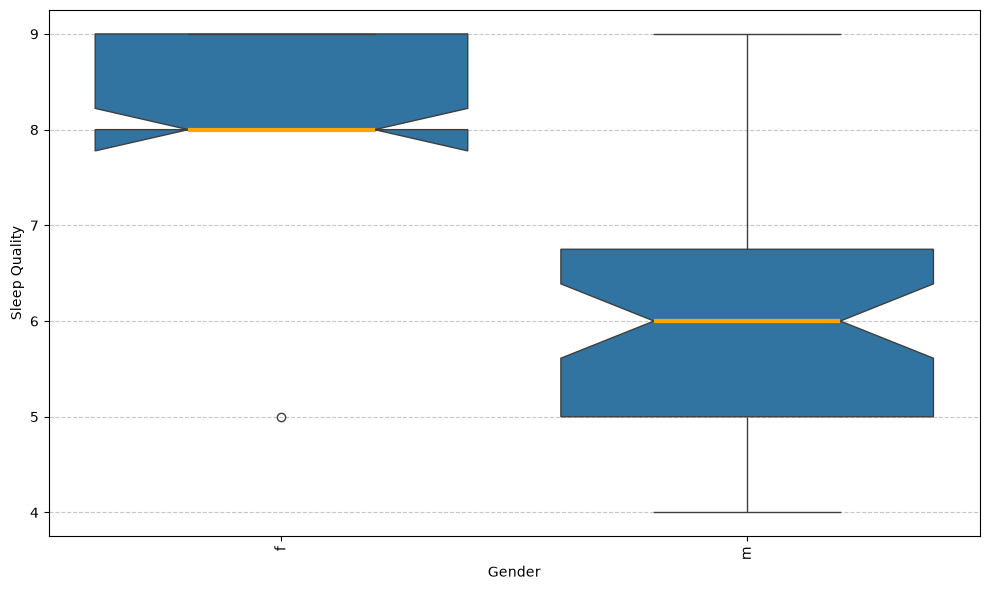

In [18]:
utils.box_plot('Gender', 'Sleep Quality', df, note=True)

<h3>Normalidad

In [15]:
import scipy.stats as stats

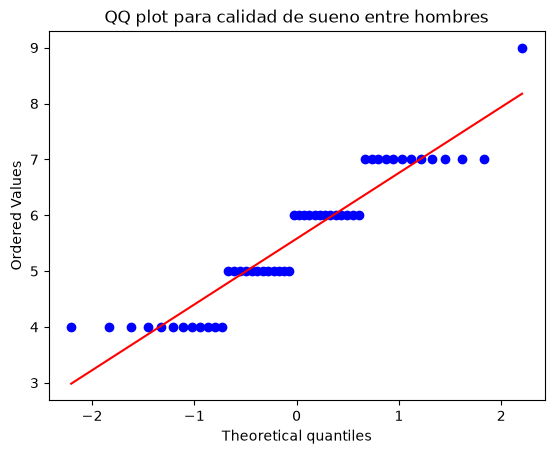

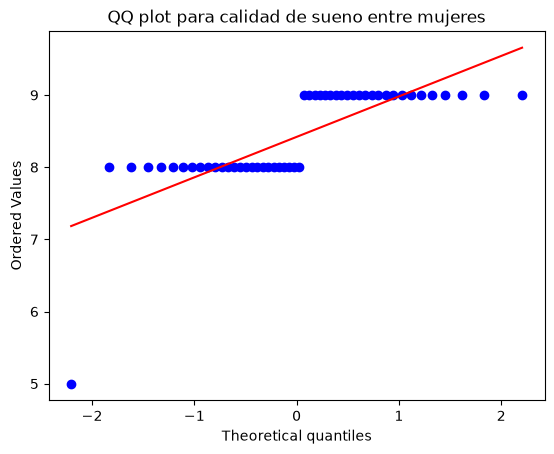

In [20]:
#QQ plot
stats.probplot(men['Sleep Quality'], dist='norm', plot=plt)
plt.title('QQ plot para calidad de sueno entre hombres')
plt.show()

stats.probplot(women['Sleep Quality'], dist='norm', plot=plt)
plt.title('QQ plot para calidad de sueno entre mujeres')
plt.show()

In [22]:
from scipy.stats import shapiro

In [ ]:
stat, p = shapiro(men['Sleep Quality'])
print(f"Test de Shapiro-Wilk para calidad de sueno en hombres: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para muertes infantibles durante 2013: Estadístico=0.889, p-valor=0.000


In [24]:
stat, p = shapiro(women['Sleep Quality'])
print(f"Test de Shapiro-Wilk para calidad de sueno en mujeres: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para calidad de sueno en mujeres: Estadístico=0.619, p-valor=0.000


<h3>Homocedasticidad

In [26]:
stat, p = stats.levene(women['Sleep Quality'], men['Sleep Quality'])
print(f"Test de Levene para calidad de sueno: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Levene para calidad de sueno: Estadístico=11.909, p-valor=0.001


Varianzas significativamente diferentes, usamos Kruskal

<h3>Kruskal-Wallis

In [28]:
stat, p = stats.kruskal(women['Sleep Quality'], men['Sleep Quality'])
print(f"Test de Kruskal-Wallis para calidad de sueno: Estadístico={stat:.3f}, p-valor={p:.3f}")

# Interpretación de los resultados
alpha = 0.05  # Nivel de significancia
if p > alpha:
    print("No hay suficiente evidencia para rechazar la hipótesis nula.")
    print("No hay una diferencia significativa en la calidad de sueno entre hombres y mujeres.")
else:
    print("Se rechaza la hipótesis nula.")
    print("Existe una diferencia significativa en la calidad de sueno entre hombres y mujeres.")

Test de Kruskal-Wallis para calidad de sueno: Estadístico=68.976, p-valor=0.000
Se rechaza la hipótesis nula.
Existe una diferencia significativa en la calidad de sueno entre hombres y mujeres.
